## Hong Kong Real Estate Developers Share Price Study

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

### Real Estate Developers

In [2]:
dev = {
    'China Overseas Land and Investment': '0688.HK',
    'Chinese Estates Holdings': '0127.HK',
    'CK Assets': '1113.HK',
    'Emperor International': '0163.HK',
    'Great Eagle Holdings': '0041.HK',
    'Hang Lung Group': '0010.HK',
    'Henderson Land Development Company': '0012.HK',
    'K. Wah International': '0173.HK',
    'Kerry Properties': '0683.HK',
    'Lai Sun International': '0191.HK',
    'MTR Corporation': '0066.HK',
    'New World Development' : '0017.HK',
    'Sino Land': '0083.HK',
    'Sun Hung Kai Properties': '0016.HK'
}

start_date = '2013-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

stock_data = pd.DataFrame()
for name, code in dev.items():
    try: 
        data = yf.download(tickers= code, 
                           start= start_date,
                           end= end_date,
                           progress=False)
        stock_data[name] = data['Close']
    except Exception as e:
        print(f"Failed to download data for {name}. Error: {e}")

stock_data.reset_index(inplace=True)
stock_data.head()


,Date,China Overseas Land and Investment,Chinese Estates Holdings,CK Assets,Emperor International,Great Eagle Holdings,Hang Lung Group,Henderson Land Development Company,K. Wah International,Kerry Properties,Lai Sun International,MTR Corporation,New World Development,Sino Land,Sun Hung Kai Properties
0,2013-01-02,14.397820,3.256120,NaN,1.290632,11.488752,23.989382,15.951209,1.965041,18.081282,4.547724,18.603003,23.250416,6.890369,68.462219
1,2013-01-03,14.607788,3.170960,NaN,1.338656,11.666183,24.016088,15.667879,1.959843,18.148252,4.480351,18.333397,23.063215,6.938689,67.828308
2,2013-01-04,14.817757,3.100828,NaN,1.350662,11.887978,24.122952,15.795378,1.954644,18.170570,4.547724,18.423260,23.250416,6.929025,68.462219
3,2013-01-07,15.177705,3.100828,NaN,1.350662,11.998875,24.336668,16.234531,2.053416,18.215216,4.547724,18.483177,23.662266,6.919361,69.902908
4,2013-01-08,14.967733,3.090809,NaN,1.332653,11.976693,24.149658,16.319530,2.084607,18.304508,4.547724,18.543089,23.475061,6.977344,69.499527


In [3]:
stock_data[stock_data['Date'] == '2015-06-03']

,Date,China Overseas Land and Investment,Chinese Estates Holdings,CK Assets,Emperor International,Great Eagle Holdings,Hang Lung Group,Henderson Land Development Company,K. Wah International,Kerry Properties,Lai Sun International,MTR Corporation,New World Development,Sino Land,Sun Hung Kai Properties
593,2015-06-03,17.619936,9.206939,49.211956,1.264717,14.67397,21.248825,22.601513,2.573174,16.086449,4.746601,23.884825,22.996775,7.078956,82.953499


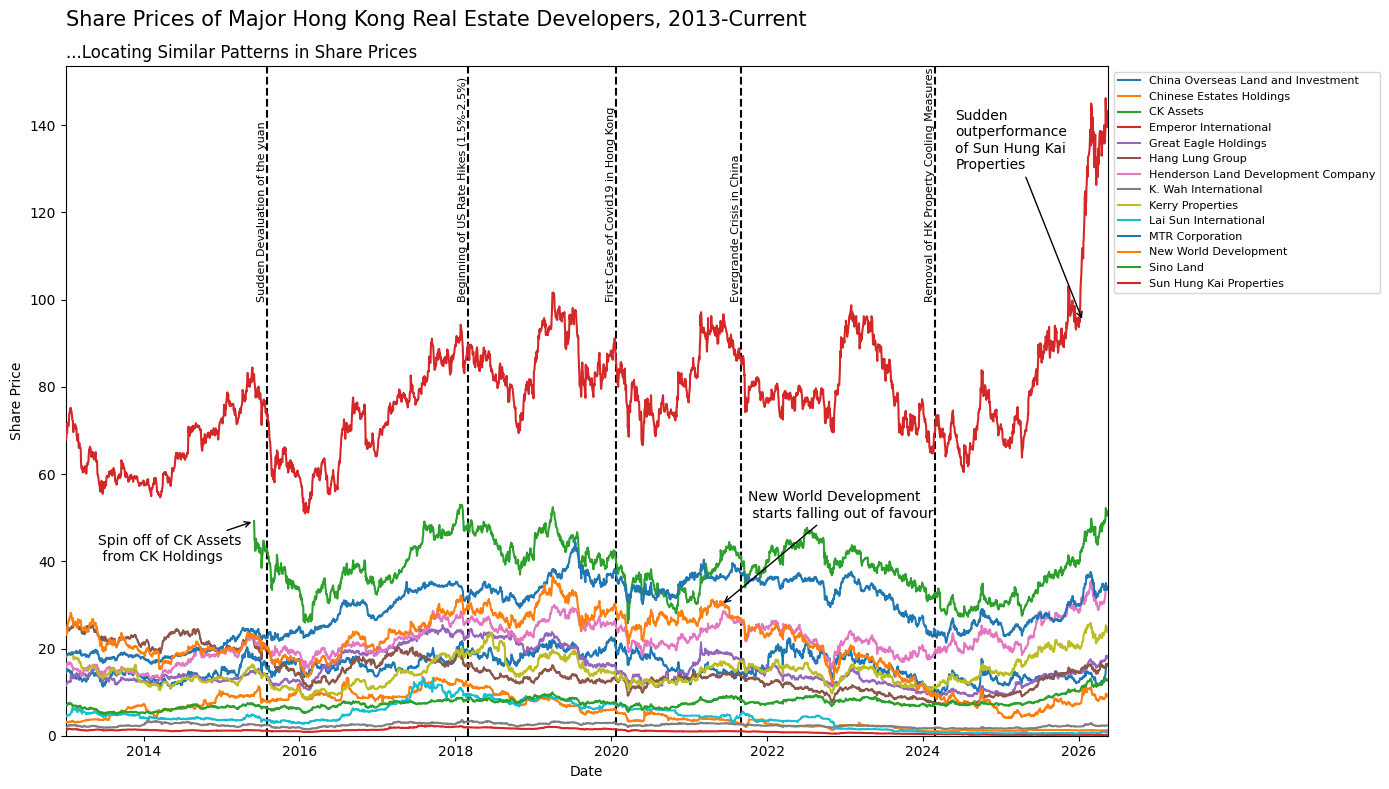

In [4]:
p1 = stock_data.melt(id_vars="Date", var_name="Developer", value_name="Share_Price")

import seaborn as sns

fig, ax = plt.subplots(figsize=(14,8))
sns.lineplot(data=p1, 
             x="Date", y = "Share_Price", 
             hue = "Developer", palette="tab10", 
             ax = ax, zorder = 3)
ax.set_ylim(bottom=0)
ax.set_xlim(left = pd.to_datetime("2013-01-01"), right = datetime.today())
ax.legend(bbox_to_anchor=(1, 1), fontsize = 8)
ax.set(xlabel="Date", ylabel= "Share Price")
ax.set_title("...Locating Similar Patterns in Share Prices", ha = "left", loc= "left")
fig.suptitle("Share Prices of Major Hong Kong Real Estate Developers, 2013-Current", fontsize = 15, x = 0.315)

## Annotations
ax.annotate("Spin off of CK Assets \n from CK Holdings", 
            xy=(pd.to_datetime("2015-06-03"), 49.2), 
            xytext=(pd.to_datetime("2013-06-01"), 40), 
            arrowprops= dict(arrowstyle = "->"))
ax.annotate("New World Development \n starts falling out of favour", 
            xy = (pd.to_datetime("2021-06-01"), 30), 
            xytext=(pd.to_datetime("2021-10-01"), 50), 
            arrowprops=dict(arrowstyle = "->"))
ax.annotate("Sudden\noutperformance\nof Sun Hung Kai\nProperties", 
            xy = (pd.to_datetime("2026-01-20"), 95), 
            xytext=(pd.to_datetime("2024-06-01"), 130), 
            arrowprops=dict(arrowstyle = "->"))

ax.axvline(x = pd.to_datetime("2015-08-01"), linestyle = "--", color = "black")
ax.annotate("Sudden Devaluation of the yuan", 
            xy=(pd.to_datetime("2015-08-01"), 100), 
            ha = "right", rotation = 90, fontsize = 8)

ax.axvline(x = pd.to_datetime("2018-03-01"), linestyle = "--", color = "black")
ax.annotate("Beginning of US Rate Hikes (1.5%-2.5%)", 
            xy=(pd.to_datetime("2018-03-01"), 100), 
            ha = "right", rotation = 90, fontsize = 8)

ax.axvline(x = pd.to_datetime("2020-01-23"), linestyle = "--", color = "black")
ax.annotate("First Case of Covid19 in Hong Kong", 
            xy=(pd.to_datetime("2020-01-23"), 100), 
            ha = "right", rotation = 90, fontsize = 8)

ax.axvline(x = pd.to_datetime("2021-09-01"), linestyle = "--", color = "black")
ax.annotate("Evergrande Crisis in China", 
            xy=(pd.to_datetime("2021-09-01"), 100), 
            ha = "right", rotation = 90, fontsize = 8)

ax.axvline(x = pd.to_datetime("2024-02-28"), linestyle = "--", color = "black")
ax.annotate("Removal of HK Property Cooling Measures", 
            xy=(pd.to_datetime("2024-02-28"), 100), 
            ha = "right", rotation = 90, fontsize = 8)

plt.tight_layout()
plt.show()